## The Universal Workflow of Machine Learning

- Define the task: Clearly specify the problem you want to solve, including the input data and the desired output.
- Develop the model: Choose an appropriate machine learning algorithm and architecture based on the task and the nature of the data.
- Deploy the model: Integrate the trained model into a production environment where it can make predictions on new data.

### Inference Model

In Deep Learning, inference refers to the process of using a trained model to make predictions on new, unseen data. The inference model is the final step in the machine learning workflow, where the trained model is deployed and used to generate predictions or classifications based on the input data. The inference model takes the learned parameters from the training phase and applies them to new data to produce outputs that can be used for decision-making, analysis, or further processing. Inference is a critical component of machine learning applications, as it allows the model to be utilized in real-world scenarios and provides insights or actions based on the data it processes.

Generate synthetic customer dataset for a retail store, including features such as day_since_signup, discount_used, average session, plan type and more. The dataset should have 6000 entries and be saved as a CSV file.

In [ ]:
import numpy as np
import pandas as pd

# Sigmoid: transforms raw score into probability
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Generate synthetic customer dataset
def generate_customer_data(n_samples=6000, production_shift=False, random_state=42):

    rng = np.random.default_rng(random_state)

    plan_type = rng.choice(["free", "basic", "pro", "enterprise"],
                           size=n_samples, p=[0.25, 0.40, 0.25, 0.10],)

    plan_risk = pd.Series(plan_type).map({"free": 0.55, "basic": 0.25,
                                          "pro": -0.05, "enterprise": -0.35,}).values

    days_since_signup = rng.gamma(2.5, 80, n_samples).clip(1, 900)
    discount_used = rng.binomial(1, 0.30, n_samples)
    visits_last_30d = rng.poisson(12, n_samples).astype(float)
    avg_session_minutes = rng.gamma(2.2, 8, n_samples).clip(0.5, 120)
    feature_adoption_score = rng.beta(2.0, 3.0, n_samples)
    email_click_rate = rng.beta(1.5, 8.0, n_samples)
    support_tickets = rng.poisson(1.0, n_samples).astype(float)

    if production_shift:
        visits_last_30d = np.maximum(0, visits_last_30d
                                     - rng.poisson(2, n_samples))

        feature_adoption_score = np.clip(feature_adoption_score
                                         - rng.normal(0.08, 0.03, n_samples), 0, 1)

        support_tickets = support_tickets + rng.poisson(0.4, n_samples)

    risk_logit = (-1.25 + plan_risk - 0.055 * visits_last_30d
                  - 0.025 * avg_session_minutes - 1.8 * feature_adoption_score
                  - 1.4 * email_click_rate + 0.30 * support_tickets
                  - 0.0015 * days_since_signup + 0.25 * discount_used
                  + rng.normal(0, 0.55, n_samples))

    churn_probability = sigmoid(risk_logit)
    churned_next_30d = rng.binomial(1, churn_probability)

    return pd.DataFrame({"days_since_signup": days_since_signup,
                         "discount_used": discount_used,
                         "visits_last_30d": visits_last_30d,
                         "avg_session_minutes": avg_session_minutes,
                         "feature_adoption_score": feature_adoption_score,
                         "email_click_rate": email_click_rate,
                         "support_tickets": support_tickets,
                         "plan_type": plan_type,
                         "churned_next_30d": churned_next_30d,})


df = generate_customer_data(6000, production_shift=False)
df.head()

,days_since_signup,discount_used,visits_last_30d,avg_session_minutes,feature_adoption_score,email_click_rate,support_tickets,plan_type,churned_next_30d
0,77.651705,0,16.0,24.071827,0.543055,0.144466,2.0,pro,0
1,123.922858,0,13.0,13.745802,0.259260,0.013556,0.0,basic,0
2,111.183723,0,8.0,25.466066,0.273688,0.181143,0.0,pro,0
3,141.637553,0,15.0,2.747935,0.349284,0.108582,1.0,pro,0
4,233.446610,1,13.0,8.845013,0.529479,0.161811,3.0,free,0


Data Split: Divide the dataset into training, validation, and test sets to evaluate the model's performance and generalization ability.

In [ ]:
from sklearn.model_selection import train_test_split

target_col = "churned_next_30d"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2,
                                                              stratify=y, random_state=42,)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full,
                                                  test_size=0.25, stratify=y_train_full, random_state=42,)

categorical_features = ["plan_type"]
numeric_features = [c for c in X.columns if c not in categorical_features]

Make model inputs: Prepare the input data for the model by performing necessary preprocessing steps such as feature scaling, encoding categorical variables, and handling missing values.

In [ ]:
def make_model_inputs(X_data):
    return {"numeric_features": X_data[numeric_features].to_numpy().astype("float32"),
            "plan_type": X_data["plan_type"].astype(str).to_numpy(),}

Compute class weights: If the dataset is imbalanced, calculate class weights to give more importance to the minority class during model training.

In [ ]:
import numpy as np

def compute_class_weight(y_values):
    y_array = np.asarray(y_values).astype(int)
    counts = np.bincount(y_array)
    total = counts.sum()

    return {0: total / (2 * counts[0]), 1: total / (2 * counts[1]),}

class_weight = compute_class_weight(y_train)

Build Keras model: Design and implement a neural network architecture using Keras, specifying the number of layers, neurons, activation functions, and other hyperparameters.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers


def build_keras_churn_model(adapt_df, hidden_units=(64, 32), dropout_rate=0.0):

    numeric_input = keras.Input(shape=(len(numeric_features),), name="numeric_features")

    normalizer = layers.Normalization()
    normalizer.adapt(adapt_df[numeric_features].to_numpy().astype("float32"))
    x_num = normalizer(numeric_input)

    plan_input = keras.Input(shape=(), dtype=tf.string, name="plan_type")

    lookup = layers.StringLookup(output_mode="one_hot")
    lookup.adapt(adapt_df["plan_type"].astype(str))
    x_plan = lookup(plan_input)

    x = layers.Concatenate()([x_num, x_plan])

    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs={"numeric_features": numeric_input, "plan_type": plan_input},
                        outputs=output)

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.BinaryAccuracy(),
                           keras.metrics.AUC(name="roc_auc"),
                           keras.metrics.AUC(curve="PR", name="pr_auc")],)

    return model

Implements early stopping: Use early stopping during model training to prevent overfitting by monitoring the validation loss and stopping training when it stops improving.

In [ ]:
model = build_keras_churn_model(X_train)

early_stopping = keras.callbacks.EarlyStopping(monitor="val_roc_auc",
                                               mode="max", patience=8,
                                               restore_best_weights=True,)

history = model.fit(make_model_inputs(X_train),
                    y_train.astype("float32"),
                    validation_data=(make_model_inputs(X_val), y_val.astype("float32")),
                    epochs=60,
                    batch_size=128,
                    class_weight=class_weight,
                    callbacks=[early_stopping], verbose=1,)

Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - binary_accuracy: 0.3803 - loss: 0.6950 - pr_auc: 0.0608 - roc_auc: 0.5173 - val_binary_accuracy: 0.6175 - val_loss: 0.6565 - val_pr_auc: 0.0887 - val_roc_auc: 0.6252
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.5028 - loss: 0.6628 - pr_auc: 0.1182 - roc_auc: 0.6547 - val_binary_accuracy: 0.5750 - val_loss: 0.6636 - val_pr_auc: 0.1085 - val_roc_auc: 0.6557
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6242 - loss: 0.6473 - pr_auc: 0.1326 - roc_auc: 0.6826 - val_binary_accuracy: 0.6350 - val_loss: 0.6301 - val_pr_auc: 0.1112 - val_roc_auc: 0.6612
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.6136 - loss: 0.6380 - pr_auc: 0.1361 - roc_auc: 0.6927 - val_binary_accuracy: 0.6058 - val_loss: 0.6389 - val_pr_auc: 0.1124 - val_roc_auc: 0.6601
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.5833 - loss: 0.6301 - pr_auc: 0.1411 - roc_auc: 0.7021 -

Make predictions: Use the trained model to make predictions on new, unseen data and evaluate the model's performance using appropriate metrics.

In [ ]:
def predict_proba(model, X_data):
    inputs = make_model_inputs(X_data)
    return model.predict(inputs, verbose=0).reshape(-1)

Evaluate model performance: Assess the model's performance using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC to determine how well it generalizes to new data.

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_proba, threshold=0.5):
    y_true = np.asarray(y_true)
    y_pred = (y_proba >= threshold).astype(int)

    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "flag_rate": y_pred.mean()}

Generate 2000 customer data used for inference, ensuring that the data is representative of the training dataset and includes a variety of feature values.

In [ ]:
df_prod = generate_customer_data(2000, production_shift=True)

X_prod = df_prod.drop(columns=["churned_next_30d"])
y_prod = df_prod["churned_next_30d"]

proba_prod = predict_proba(model, X_prod)

metrics_prod = evaluate(y_prod, proba_prod)
metrics_prod

{'roc_auc': np.float64(0.6790662721337655),
 'precision': 0.13459715639810427,
 'recall': 0.7553191489361702,
 'f1': 0.22847948511665325,
 'flag_rate': np.float64(0.5275)}

Visualize model learning: Visualize how the model learns over time by plotting both training and validation loss, as well as training and validation accuracy.

In [ ]:
import matplotlib.pyplot as plt

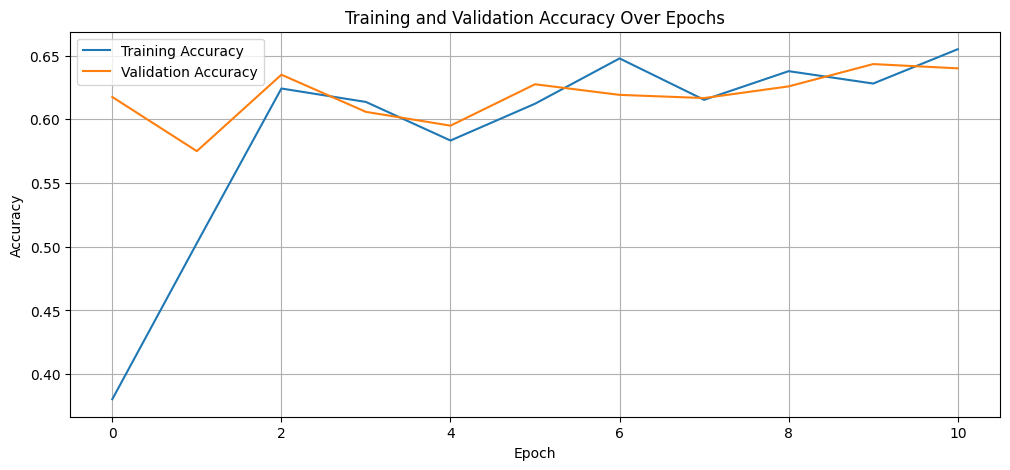

In [ ]:
fig_acc = plt.figure(figsize=(12, 5))
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

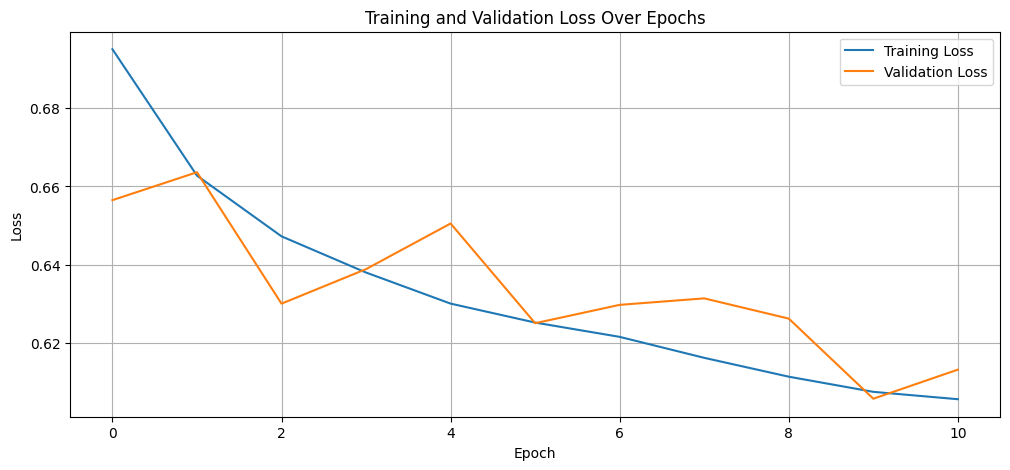

In [ ]:
fig_loss = plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()